# AI Interior Design Visualizer

Tagline: Redecorate your room before buying a single thing.

This notebook is a product prototype for a browser-based room redesign workflow. It shows how a user-uploaded room photo can flow through room-region segmentation, wall recoloring, furniture style swapping, palette recommendation, and a Flask API payload that a React + Fabric.js frontend can consume.

The notebook is intentionally lightweight and reproducible. If a real room photo or a SAM checkpoint is not available, it falls back to a synthetic room scene so the rest of the pipeline still runs end to end.

Covered in this notebook:

1. Environment setup and helper utilities
2. Room image loading or synthetic scene generation
3. Segmentation masks for walls, floor, and furniture
4. Mask-to-vector conversion for Fabric.js layers
5. Wall color swaps and furniture style presets
6. Palette recommendation and shareable redesign payloads


In [1]:
from __future__ import annotations

import hashlib
import json
from pathlib import Path
from typing import Any

import cv2
import matplotlib.pyplot as plt
import numpy as np

try:
    import torch
except ImportError:
    torch = None

try:
    from flask import Flask, jsonify, request
except ImportError:
    Flask = None
    jsonify = None
    request = None

try:
    from segment_anything import SamPredictor, sam_model_registry
except ImportError:
    SamPredictor = None
    sam_model_registry = None


PROJECT_ROOT = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / 'README.md').exists()),
    Path.cwd(),
)
NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks'
OUTPUT_DIR = NOTEBOOK_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAM_CHECKPOINT = NOTEBOOK_DIR / 'checkpoints' / 'sam_vit_b_01ec64.pth'
ROOM_IMAGE_CANDIDATES = [
    PROJECT_ROOT / 'data' / 'room.jpg',
    PROJECT_ROOT / 'data' / 'room.png',
    PROJECT_ROOT / 'frontend' / 'public' / 'room.jpg',
    PROJECT_ROOT / 'frontend' / 'public' / 'room.png',
    PROJECT_ROOT / 'assets' / 'room.jpg',
    PROJECT_ROOT / 'assets' / 'room.png',
]

STYLE_THEMES = {
    'scandinavian': {
        'wall': [244, 239, 232],
        'sofa': [233, 226, 218],
        'wood': [199, 175, 145],
        'accent': [165, 191, 183],
    },
    'modern_luxe': {
        'wall': [226, 220, 214],
        'sofa': [58, 62, 70],
        'wood': [139, 104, 84],
        'accent': [192, 153, 105],
    },
    'japandi': {
        'wall': [238, 232, 222],
        'sofa': [208, 198, 184],
        'wood': [176, 143, 108],
        'accent': [124, 145, 133],
    },
    'industrial': {
        'wall': [225, 225, 226],
        'sofa': [94, 97, 104],
        'wood': [112, 93, 81],
        'accent': [173, 124, 98],
    },
}


def rgb_to_hex(rgb: np.ndarray | list[int] | tuple[int, int, int]) -> str:
    red, green, blue = [int(value) for value in rgb]
    return f'#{red:02x}{green:02x}{blue:02x}'


def show_side_by_side(left: np.ndarray, right: np.ndarray, left_title: str, right_title: str, figsize=(14, 6)):
    figure, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].imshow(left)
    axes[0].set_title(left_title)
    axes[0].axis('off')
    axes[1].imshow(right)
    axes[1].set_title(right_title)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


def build_rect_mask(shape: tuple[int, int], rectangles: list[tuple[int, int, int, int]]) -> np.ndarray:
    mask = np.zeros(shape, dtype=bool)
    for x1, y1, x2, y2 in rectangles:
        mask[y1:y2, x1:x2] = True
    return mask


def overlay_mask(image_rgb: np.ndarray, mask: np.ndarray, color: tuple[int, int, int], alpha: float = 0.55) -> np.ndarray:
    overlay = image_rgb.copy().astype(np.float32)
    color_array = np.array(color, dtype=np.float32)
    overlay[mask] = overlay[mask] * (1.0 - alpha) + color_array * alpha
    return np.clip(overlay, 0, 255).astype(np.uint8)


def mask_to_svg_layers(mask: np.ndarray, layer_name: str, stroke: str, fill: str, min_area: float = 80.0) -> list[dict[str, Any]]:
    mask_uint8 = (mask.astype(np.uint8)) * 255
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    layers: list[dict[str, Any]] = []
    for index, contour in enumerate(contours):
        area = float(cv2.contourArea(contour))
        if area < min_area:
            continue
        epsilon = max(2.0, 0.01 * cv2.arcLength(contour, True))
        approximation = cv2.approxPolyDP(contour, epsilon, True)
        points = approximation.reshape(-1, 2)
        if len(points) == 0:
            continue
        path_parts = [f'M {int(points[0][0])} {int(points[0][1])}']
        for x_value, y_value in points[1:]:
            path_parts.append(f'L {int(x_value)} {int(y_value)}')
        path_parts.append('Z')
        svg_path = ' '.join(path_parts)
        x, y, width, height = cv2.boundingRect(approximation)
        layers.append(
            {
                'id': f'{layer_name}-{index + 1}',
                'svgPath': svg_path,
                'polygon': points.tolist(),
                'bbox': {'x': int(x), 'y': int(y), 'width': int(width), 'height': int(height)},
                'area': area,
                'fabricPathConfig': {
                    'path': svg_path,
                    'fill': fill,
                    'stroke': stroke,
                    'strokeWidth': 2,
                    'strokeUniform': True,
                },
            }
        )
    return layers


def make_demo_room(width: int = 960, height: int = 640) -> tuple[np.ndarray, dict[str, Any]]:
    image = np.full((height, width, 3), (238, 232, 224), dtype=np.uint8)
    cv2.rectangle(image, (0, int(height * 0.58)), (width, height), (191, 168, 144), -1)
    cv2.rectangle(image, (65, 62), (330, 255), (228, 244, 250), -1)
    cv2.rectangle(image, (86, 84), (309, 234), (255, 255, 255), 6)
    cv2.rectangle(image, (170, 300), (680, 520), (80, 84, 92), -1)
    cv2.rectangle(image, (205, 330), (645, 500), (116, 120, 130), -1)
    cv2.rectangle(image, (500, 286), (710, 466), (235, 226, 212), -1)
    cv2.circle(image, (715, 248), 44, (214, 188, 150), -1)
    cv2.rectangle(image, (744, 140), (888, 520), (213, 203, 190), -1)
    cv2.rectangle(image, (735, 120), (900, 540), (194, 181, 164), 5)
    layout = {
        'wall': [(0, 0, width, int(height * 0.58))],
        'floor': [(0, int(height * 0.58), width, height)],
        'sofa': [(170, 300, 680, 520)],
        'table': [(500, 286, 710, 466)],
        'lamp': [(690, 160, 770, 330)],
        'plant': [(745, 140, 888, 520)],
    }
    return image, layout


def load_room_image() -> tuple[np.ndarray, str, dict[str, Any]]:
    for candidate in ROOM_IMAGE_CANDIDATES:
        if candidate.exists():
            image_bgr = cv2.imread(str(candidate), cv2.IMREAD_COLOR)
            if image_bgr is None:
                continue
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            return image_rgb, 'uploaded_photo', {}
    image_rgb, layout = make_demo_room()
    return image_rgb, 'synthetic_demo', layout


def try_build_sam_predictor(checkpoint_path: Path):
    if torch is None or SamPredictor is None or sam_model_registry is None:
        return None
    if not checkpoint_path.exists():
        return None
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    sam = sam_model_registry['vit_b'](checkpoint=str(checkpoint_path))
    sam.to(device=device)
    sam.eval()
    return SamPredictor(sam)


print('Project root:', PROJECT_ROOT)
print('Output directory:', OUTPUT_DIR)
print('SAM checkpoint exists:', SAM_CHECKPOINT.exists())
print('Torch available:', torch is not None)
print('Flask available:', Flask is not None)


Project root: s:\AI Interior Design Visualizer
Output directory: s:\AI Interior Design Visualizer\notebooks\outputs
SAM checkpoint exists: False
Torch available: True
Flask available: True


## Room Image and Product Goal

The frontend starts with a user-uploaded room photo. For notebook reproducibility, the pipeline can also fall back to a synthetic demo room that contains walls, floor, sofa, table, lamp, and decor regions. That gives us a stable substrate for testing segmentation, recoloring, and furniture replacement without blocking on external assets.

In the browser app, the same contract supports three user actions:

1. Change wall colors with AI-suggested palette combinations.
2. Swap furniture styles using catalog items or style-transfer presets.
3. Save and share the resulting redesign as a JSON payload plus preview image.


Image source: synthetic_demo
Room image shape: (640, 960, 3)


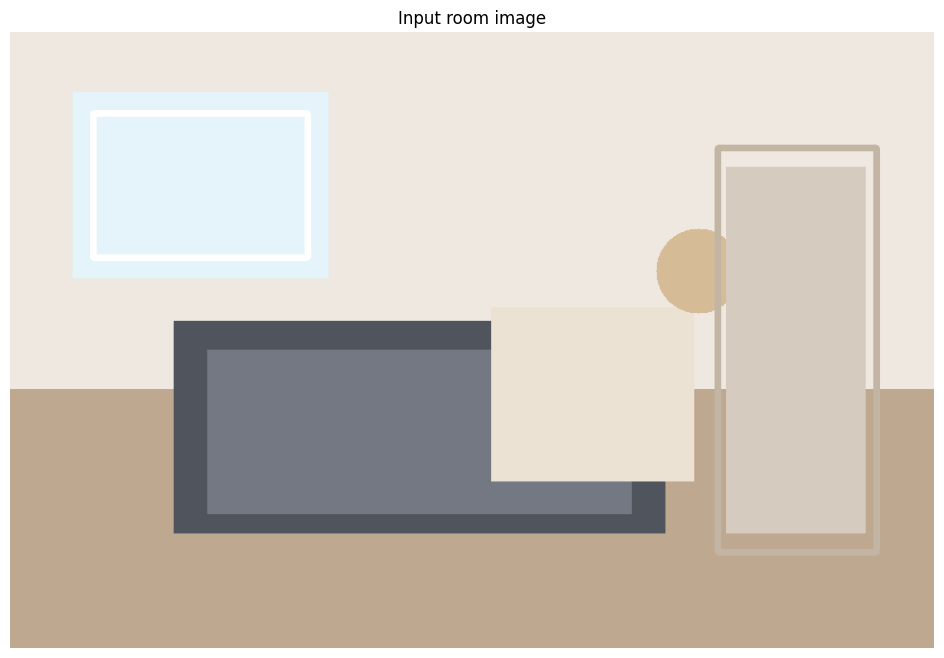

Synthetic layout keys: ['floor', 'lamp', 'plant', 'sofa', 'table', 'wall']


In [2]:
room_image_rgb, image_source, scene_layout = load_room_image()
room_height, room_width = room_image_rgb.shape[:2]
print('Image source:', image_source)
print('Room image shape:', room_image_rgb.shape)

plt.figure(figsize=(14, 8))
plt.imshow(room_image_rgb)
plt.title('Input room image')
plt.axis('off')
plt.show()

if scene_layout:
    print('Synthetic layout keys:', sorted(scene_layout.keys()))
else:
    print('No synthetic layout was needed for this image.')


## Segmentation and Region Modeling

The redesign pipeline begins by separating the room into editable semantic regions. In production, this can come from SAM prompts on the uploaded photo. In the notebook, the same contract is supported by a deterministic fallback so the rest of the workflow remains testable.

Regions we care about most:

1. Wall surfaces for paint and wallpaper changes.
2. Floor surfaces for rug and finish exploration.
3. Furniture and decor objects for style swaps.


Regions available: ['wall', 'floor', 'sofa', 'table', 'lamp', 'plant']
Wall pixels: 356160
Furniture pixels: 112200
Vector layer count: 6


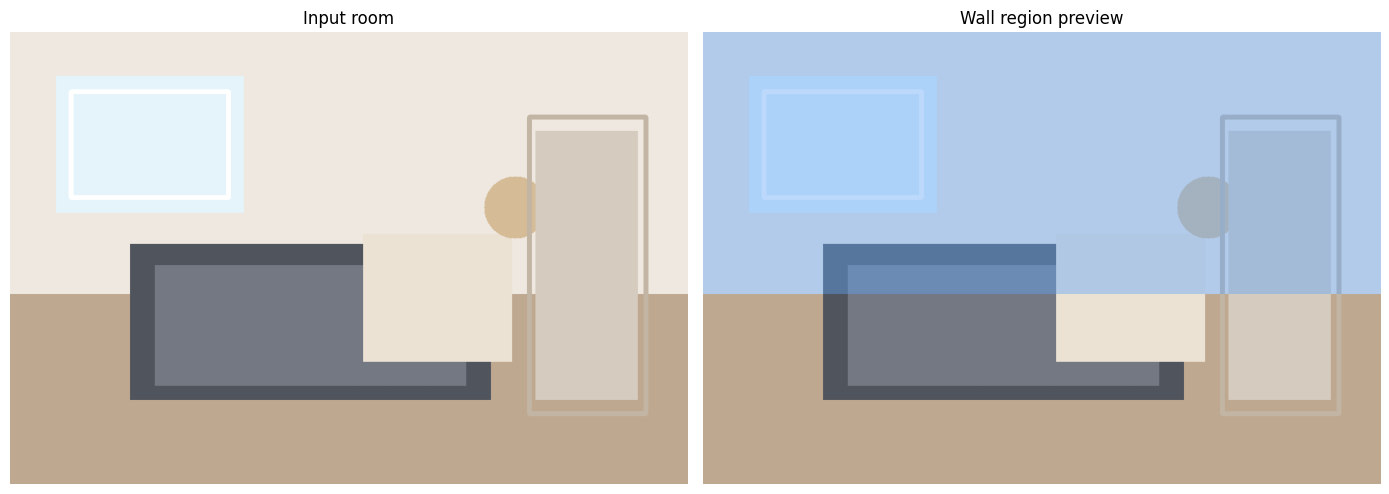

In [3]:
def build_room_masks(image_rgb: np.ndarray, image_source: str, scene_layout: dict[str, Any]) -> dict[str, np.ndarray]:
    height, width = image_rgb.shape[:2]
    masks: dict[str, np.ndarray] = {}

    if image_source == 'synthetic_demo' and scene_layout:
        for name, rectangles in scene_layout.items():
            masks[name] = build_rect_mask((height, width), rectangles)
        return masks

    predictor = try_build_sam_predictor(SAM_CHECKPOINT)
    if predictor is not None:
        predictor.set_image(image_rgb)
        prompt_points = {
            'wall': (int(width * 0.50), int(height * 0.18)),
            'floor': (int(width * 0.50), int(height * 0.82)),
            'sofa': (int(width * 0.35), int(height * 0.72)),
            'table': (int(width * 0.58), int(height * 0.60)),
            'lamp': (int(width * 0.75), int(height * 0.35)),
            'plant': (int(width * 0.84), int(height * 0.62)),
        }
        for name, point in prompt_points.items():
            point_coords = np.array([point], dtype=np.float32)
            point_labels = np.array([1], dtype=np.int32)
            predicted_masks, scores, _ = predictor.predict(
                point_coords=point_coords,
                point_labels=point_labels,
                multimask_output=True,
            )
            best_index = int(np.argmax(scores))
            masks[name] = predicted_masks[best_index].astype(bool)
        return masks

    wall_mask = np.zeros((height, width), dtype=bool)
    floor_mask = np.zeros((height, width), dtype=bool)
    furniture_mask = np.zeros((height, width), dtype=bool)
    wall_mask[: int(height * 0.58), :] = True
    floor_mask[int(height * 0.58) :, :] = True
    furniture_mask[int(height * 0.46) : int(height * 0.88), int(width * 0.10) : int(width * 0.90)] = True
    masks['wall'] = wall_mask
    masks['floor'] = floor_mask
    masks['sofa'] = furniture_mask
    masks['table'] = build_rect_mask((height, width), [(int(width * 0.52), int(height * 0.46), int(width * 0.73), int(height * 0.72))])
    masks['lamp'] = build_rect_mask((height, width), [(int(width * 0.72), int(height * 0.25), int(width * 0.80), int(height * 0.58))])
    masks['plant'] = build_rect_mask((height, width), [(int(width * 0.80), int(height * 0.20), int(width * 0.92), int(height * 0.86))])
    return masks


region_masks = build_room_masks(room_image_rgb, image_source, scene_layout)
mask_names = list(region_masks.keys())
print('Regions available:', mask_names)
print('Wall pixels:', int(region_masks['wall'].sum()) if 'wall' in region_masks else 0)
print('Furniture pixels:', int(region_masks['sofa'].sum()) if 'sofa' in region_masks else 0)

mask_layers = {
    name: mask_to_svg_layers(mask, name, stroke='#ea580c', fill='rgba(255, 255, 255, 0.16)')
    for name, mask in region_masks.items()
}
vector_layer_count = sum(len(layers) for layers in mask_layers.values())
print('Vector layer count:', vector_layer_count)

region_preview = overlay_mask(room_image_rgb, region_masks['wall'], (96, 165, 250), alpha=0.42)
show_side_by_side(room_image_rgb, region_preview, 'Input room', 'Wall region preview')


## Wall Colors, Style Transfer, and Palette Suggestions

This is the creative layer of the product. The same mask contract can drive three different kinds of edits:

1. Wall recoloring for paint or wallpaper exploration.
2. Furniture style shifts using catalog presets or learned style-transfer models.
3. Palette suggestions that balance dominant, secondary, and accent colors before the user commits to a redesign.


Room palette:
{
  "kmeansCompactness": 137806977.20731163,
  "regionPixelCount": 614400,
  "swatches": [
    {
      "rank": 0,
      "rgb": [
        237,
        233,
        227
      ],
      "hex": "#ede9e3",
      "share": 0.5046
    },
    {
      "rank": 1,
      "rgb": [
        192,
        169,
        145
      ],
      "hex": "#c0a991",
      "share": 0.2709
    },
    {
      "rank": 2,
      "rgb": [
        104,
        108,
        117
      ],
      "hex": "#686c75",
      "share": 0.1346
    },
    {
      "rank": 3,
      "rgb": [
        213,
        203,
        190
      ],
      "hex": "#d5cbbe",
      "share": 0.0899
    }
  ],
  "roles": {
    "dominant": {
      "weight": 60,
      "swatch": {
        "rank": 0,
        "rgb": [
          237,
          233,
          227
        ],
        "hex": "#ede9e3",
        "share": 0.5046
      }
    },
    "secondary": {
      "weight": 30,
      "swatch": {
        "rank": 1,
        "rgb": [
          192,
      

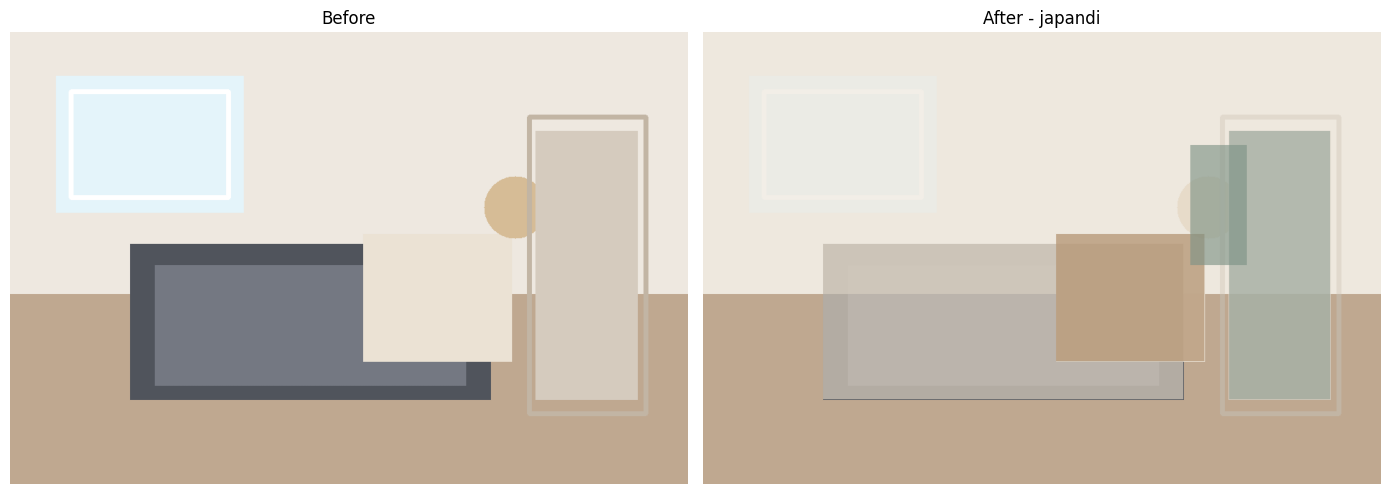

In [4]:
def extract_region_palette(image_rgb: np.ndarray, mask: np.ndarray, k: int = 4) -> dict[str, Any]:
    if mask.dtype != np.bool_:
        mask = mask.astype(bool)

    pixels = image_rgb[mask]
    if pixels.size == 0:
        return {
            'regionPixelCount': 0,
            'swatches': [],
            'roles': {},
        }

    samples = pixels.astype(np.float32)
    unique_samples = np.unique(samples, axis=0)
    cluster_count = max(1, min(k, len(unique_samples)))

    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        25,
        1.0,
    )
    compactness, labels, centers = cv2.kmeans(
        samples,
        cluster_count,
        None,
        criteria,
        8,
        cv2.KMEANS_PP_CENTERS,
    )

    counts = np.bincount(labels.flatten(), minlength=cluster_count)
    total = float(counts.sum()) if counts.sum() > 0 else 1.0
    ranked_indices = np.argsort(counts)[::-1]

    swatches: list[dict[str, Any]] = []
    for rank, index in enumerate(ranked_indices):
        rgb = np.clip(np.round(centers[index]), 0, 255).astype(int)
        swatches.append(
            {
                'rank': rank,
                'rgb': [int(rgb[0]), int(rgb[1]), int(rgb[2])],
                'hex': rgb_to_hex(rgb),
                'share': round(float(counts[index]) / total, 4),
            }
        )

    dominant = swatches[0] if swatches else None
    secondary = swatches[1] if len(swatches) > 1 else dominant
    accent = swatches[2] if len(swatches) > 2 else secondary
    return {
        'kmeansCompactness': float(compactness),
        'regionPixelCount': int(len(pixels)),
        'swatches': swatches,
        'roles': {
            'dominant': {'weight': 60, 'swatch': dominant},
            'secondary': {'weight': 30, 'swatch': secondary},
            'accent': {'weight': 10, 'swatch': accent},
        },
    }


def apply_tint(image_rgb: np.ndarray, mask: np.ndarray, target_rgb: list[int] | tuple[int, int, int], strength: float = 0.68) -> np.ndarray:
    result = image_rgb.copy().astype(np.float32)
    target = np.array(target_rgb, dtype=np.float32)
    result[mask] = result[mask] * (1.0 - strength) + target * strength
    return np.clip(result, 0, 255).astype(np.uint8)


def suggest_wall_palettes(room_palette: dict[str, Any]) -> list[dict[str, Any]]:
    swatches = room_palette.get('swatches', [])
    base = swatches[0]['hex'] if len(swatches) > 0 else '#f0e8dc'
    secondary = swatches[1]['hex'] if len(swatches) > 1 else '#d8c7b5'
    accent = swatches[2]['hex'] if len(swatches) > 2 else '#9aa7a1'
    return [
        {'name': 'Warm Minimal', 'wall': base, 'trim': '#ffffff', 'accent': accent},
        {'name': 'Soft Contrast', 'wall': secondary, 'trim': '#f8f3ef', 'accent': base},
        {'name': 'Calm Studio', 'wall': '#e8dfd5', 'trim': '#f4f1ed', 'accent': '#8ea3a0'},
    ]


def apply_style_theme(image_rgb: np.ndarray, masks: dict[str, np.ndarray], theme_name: str) -> np.ndarray:
    theme = STYLE_THEMES[theme_name]
    result = image_rgb.copy()
    if 'wall' in masks:
        result = apply_tint(result, masks['wall'], theme['wall'], strength=0.72)
    if 'sofa' in masks:
        result = apply_tint(result, masks['sofa'], theme['sofa'], strength=0.78)
    if 'table' in masks:
        result = apply_tint(result, masks['table'], theme['wood'], strength=0.70)
    if 'lamp' in masks:
        result = apply_tint(result, masks['lamp'], theme['accent'], strength=0.62)
    if 'plant' in masks:
        result = apply_tint(result, masks['plant'], theme['accent'], strength=0.48)
    return result


full_room_mask = np.ones(room_image_rgb.shape[:2], dtype=bool)
room_palette = extract_region_palette(room_image_rgb, full_room_mask, k=4)
palette_suggestions = suggest_wall_palettes(room_palette)
selected_theme_name = 'japandi'
redesigned_room_rgb = apply_style_theme(room_image_rgb, region_masks, selected_theme_name)

print('Room palette:')
print(json.dumps(room_palette, indent=2))
print('Palette suggestions:')
print(json.dumps(palette_suggestions, indent=2))
print('Selected theme:', selected_theme_name)

show_side_by_side(room_image_rgb, redesigned_room_rgb, 'Before', f'After - {selected_theme_name}')


## Frontend Contract: React, Fabric.js, and Drag-and-Drop

This notebook also defines the data shape the browser consumes. The frontend can render a side-by-side before/after view, place editable Fabric.js overlays on top of the room photo, and let the user drag furniture cards from a catalog into the scene.

The core payload includes:

1. The original room image metadata.
2. Semantic masks and vector paths for each editable region.
3. A recommended palette plus the active redesign choice.
4. A furniture catalog that the React UI can turn into draggable cards.
5. A share token or saved JSON artifact for revisiting a redesign later.


In [5]:
furniture_catalog = [
    {
        'id': 'sofa-midcentury',
        'label': 'Mid-century sofa',
        'category': 'sofa',
        'style': 'warm modern',
        'previewColor': '#7b6d62',
    },
    {
        'id': 'chair-scandi',
        'label': 'Scandinavian lounge chair',
        'category': 'chair',
        'style': 'airy minimal',
        'previewColor': '#d9d2c7',
    },
    {
        'id': 'table-wood',
        'label': 'Oak coffee table',
        'category': 'table',
        'style': 'natural',
        'previewColor': '#c8a47d',
    },
    {
        'id': 'lamp-arc',
        'label': 'Arc floor lamp',
        'category': 'lamp',
        'style': 'statement',
        'previewColor': '#b88a5a',
    },
]

fabric_layers = [layer for layers in mask_layers.values() for layer in layers]
active_wall_palette = palette_suggestions[0]
redesign_summary = {
    'styleTheme': selected_theme_name,
    'wallPalette': active_wall_palette,
    'catalogItems': furniture_catalog,
    'vectorLayers': fabric_layers,
}


def build_design_payload() -> dict[str, Any]:
    return {
        'source': {
            'imageSource': image_source,
            'imageSize': {'width': int(room_width), 'height': int(room_height)},
        },
        'regions': {
            name: {
                'pixelCount': int(mask.sum()),
                'vectorLayerCount': len(mask_layers.get(name, [])),
            }
            for name, mask in region_masks.items()
        },
        'palette': {
            'roomPalette': room_palette,
            'recommendations': palette_suggestions,
            'activeChoice': active_wall_palette,
        },
        'design': {
            'styleTheme': selected_theme_name,
            'beforeAfter': {
                'beforeLabel': 'Original',
                'afterLabel': f'After - {selected_theme_name}',
            },
            'catalog': furniture_catalog,
        },
        'frontendContracts': {
            'fabricLayers': fabric_layers,
            'shareableSummary': redesign_summary,
        },
    }


def save_design_payload(payload: dict[str, Any]) -> tuple[str, Path]:
    payload_text = json.dumps(payload, indent=2, sort_keys=True)
    design_id = hashlib.sha1(payload_text.encode('utf-8')).hexdigest()[:12]
    payload_path = OUTPUT_DIR / f'design_{design_id}.json'
    payload_path.write_text(payload_text, encoding='utf-8')
    return design_id, payload_path


def create_app() -> Flask | None:
    if Flask is None:
        return None

    app = Flask(__name__)

    @app.get('/health')
    def health_check():
        return jsonify({'status': 'ok'})

    @app.post('/api/redesign')
    def redesign_endpoint():
        request_body = request.get_json(force=True) or {}
        return jsonify(
            {
                'status': 'ok',
                'receivedKeys': sorted(request_body.keys()),
                'preview': redesign_summary,
            }
        )

    @app.get('/api/share/<design_id>')
    def share_endpoint(design_id: str):
        return jsonify({'designId': design_id, 'message': 'Fetch the saved redesign JSON from storage.'})

    return app


design_payload = build_design_payload()
design_id, design_path = save_design_payload(design_payload)
flask_app = create_app()

print('Design id:', design_id)
print('Saved payload:', design_path)
print('Payload keys:', sorted(design_payload.keys()))
print('Furniture catalog items:', len(furniture_catalog))
print(json.dumps(design_payload, indent=2))


Design id: 6977d51ef4de
Saved payload: s:\AI Interior Design Visualizer\notebooks\outputs\design_6977d51ef4de.json
Payload keys: ['design', 'frontendContracts', 'palette', 'regions', 'source']
Furniture catalog items: 4
{
  "source": {
    "imageSource": "synthetic_demo",
    "imageSize": {
      "width": 960,
      "height": 640
    }
  },
  "regions": {
    "wall": {
      "pixelCount": 356160,
      "vectorLayerCount": 1
    },
    "floor": {
      "pixelCount": 258240,
      "vectorLayerCount": 1
    },
    "sofa": {
      "pixelCount": 112200,
      "vectorLayerCount": 1
    },
    "table": {
      "pixelCount": 37800,
      "vectorLayerCount": 1
    },
    "lamp": {
      "pixelCount": 13600,
      "vectorLayerCount": 1
    },
    "plant": {
      "pixelCount": 54340,
      "vectorLayerCount": 1
    }
  },
  "palette": {
    "roomPalette": {
      "kmeansCompactness": 137806977.20731163,
      "regionPixelCount": 614400,
      "swatches": [
        {
          "rank": 0,
        